# Notebook 02 — In-Sample Model Comparison

This notebook fits all regime-switching models on the **pre-break** training sample
and evaluates their **in-sample** performance: how well do they recover the
true latent regimes and forecast ``y``?

**Models compared**
- Markov Switching Regression (MSM) — classical EM/Hamilton filter
- Hidden Markov Model (HMM) + per-regime Ridge
- Threshold Autoregression (TAR)
- ML Regime Switcher (KMeans + XGBoost)
- Mixture of Experts (EM soft-assignment)

**Metrics**
- Regime detection accuracy & Adjusted Rand Index
- Forecast RMSE and MAE
- Directional accuracy

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from simulation import MarkovSwitchingDGP
from simulation.lucas_shift import MILD_SHIFT, simulate_pre_post_break
from models import HMMRegimeModel, ThresholdModel, MLRegimeModel, MixtureOfExpertsModel
from models import MarkovSwitchingNeuralNetwork
from evaluation.metrics import (
    forecast_rmse, forecast_mae, directional_accuracy,
    regime_accuracy, adjusted_rand_regime, regime_conditional_rmse,
)
from evaluation.visualization import (
    plot_regime_comparison, plot_model_comparison_bar, save_figure
)

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
data_dir = PROJECT_ROOT / 'data' / 'simulated'

if (data_dir / 'pre_break.parquet').exists():
    df_train = pd.read_parquet(data_dir / 'pre_break.parquet')
    print('Loaded pre-break data from parquet.')
else:
    dgp = MarkovSwitchingDGP(seed=42)
    df_train, _, _ = simulate_pre_post_break(dgp, MILD_SHIFT, n_pre=400, n_post=200)
    print('Simulated fresh pre-break data.')

print(f'Training set: {len(df_train)} observations')
print(df_train['regime_label'].value_counts())

Loaded pre-break data from parquet.
Training set: 381 observations
regime_label
recession    251
expansion    130
Name: count, dtype: int64


## 2. Fit All Models

In [3]:
models = {
    'HMM': HMMRegimeModel(n_components=2, random_state=42),
    'Threshold (TAR)': ThresholdModel(),
    'ML Regime (XGB)': MLRegimeModel(n_regimes=2),
    'Mixture of Experts': MixtureOfExpertsModel(n_experts=2, n_iter=50, random_state=42),
    'MSNN': MarkovSwitchingNeuralNetwork(
        k_regimes=2,
        hidden_layer_sizes=(32, 16),
        n_iter=50,
        mlp_epochs=200,
        random_state=42,
    ),
}

# Add Markov Switching if statsmodels available
try:
    from models import MarkovSwitchingModel
    models['Markov Switching (MSM)'] = MarkovSwitchingModel(k_regimes=2, switching_variance=True)
    print('Markov Switching (MSM) added.')
except Exception as e:
    print(f'MSM not available: {e}')

print(f'Fitting {len(models)} models...')
for name, model in models.items():
    print(f'  Fitting {name}...')
    model.fit(df_train)
    print(f'    Done.')

Markov Switching (MSM) added.
Fitting 6 models...
  Fitting HMM...
    Done.
  Fitting Threshold (TAR)...
    Done.
  Fitting ML Regime (XGB)...
    Done.
  Fitting Mixture of Experts...
    Done.
  Fitting MSNN...
    Done.
  Fitting Markov Switching (MSM)...
    Done.


## 3. Regime Recovery

In [4]:
true_regimes = df_train['regime'].to_numpy()
pred_regimes = {}

for name, model in models.items():
    try:
        pred_regimes[name] = model.predict_regimes(df_train)
    except Exception as e:
        print(f'{name} predict_regimes failed: {e}')

print('Regime detection performance:')
print(f'{"Model":<25} {"Accuracy":<12} {"ARI":<10}')
print('-' * 47)
for name, pred in pred_regimes.items():
    acc = regime_accuracy(true_regimes, pred)
    ari = adjusted_rand_regime(true_regimes, pred)
    print(f'{name:<25} {acc:<12.4f} {ari:<10.4f}')

Regime detection performance:
Model                     Accuracy     ARI       
-----------------------------------------------
HMM                       0.7507       0.2494    
Threshold (TAR)           0.5013       -0.0450   
ML Regime (XGB)           0.6640       0.1028    
Mixture of Experts        0.5354       -0.0238   
MSNN                      0.5144       -0.0058   
Markov Switching (MSM)    0.8058       0.3569    


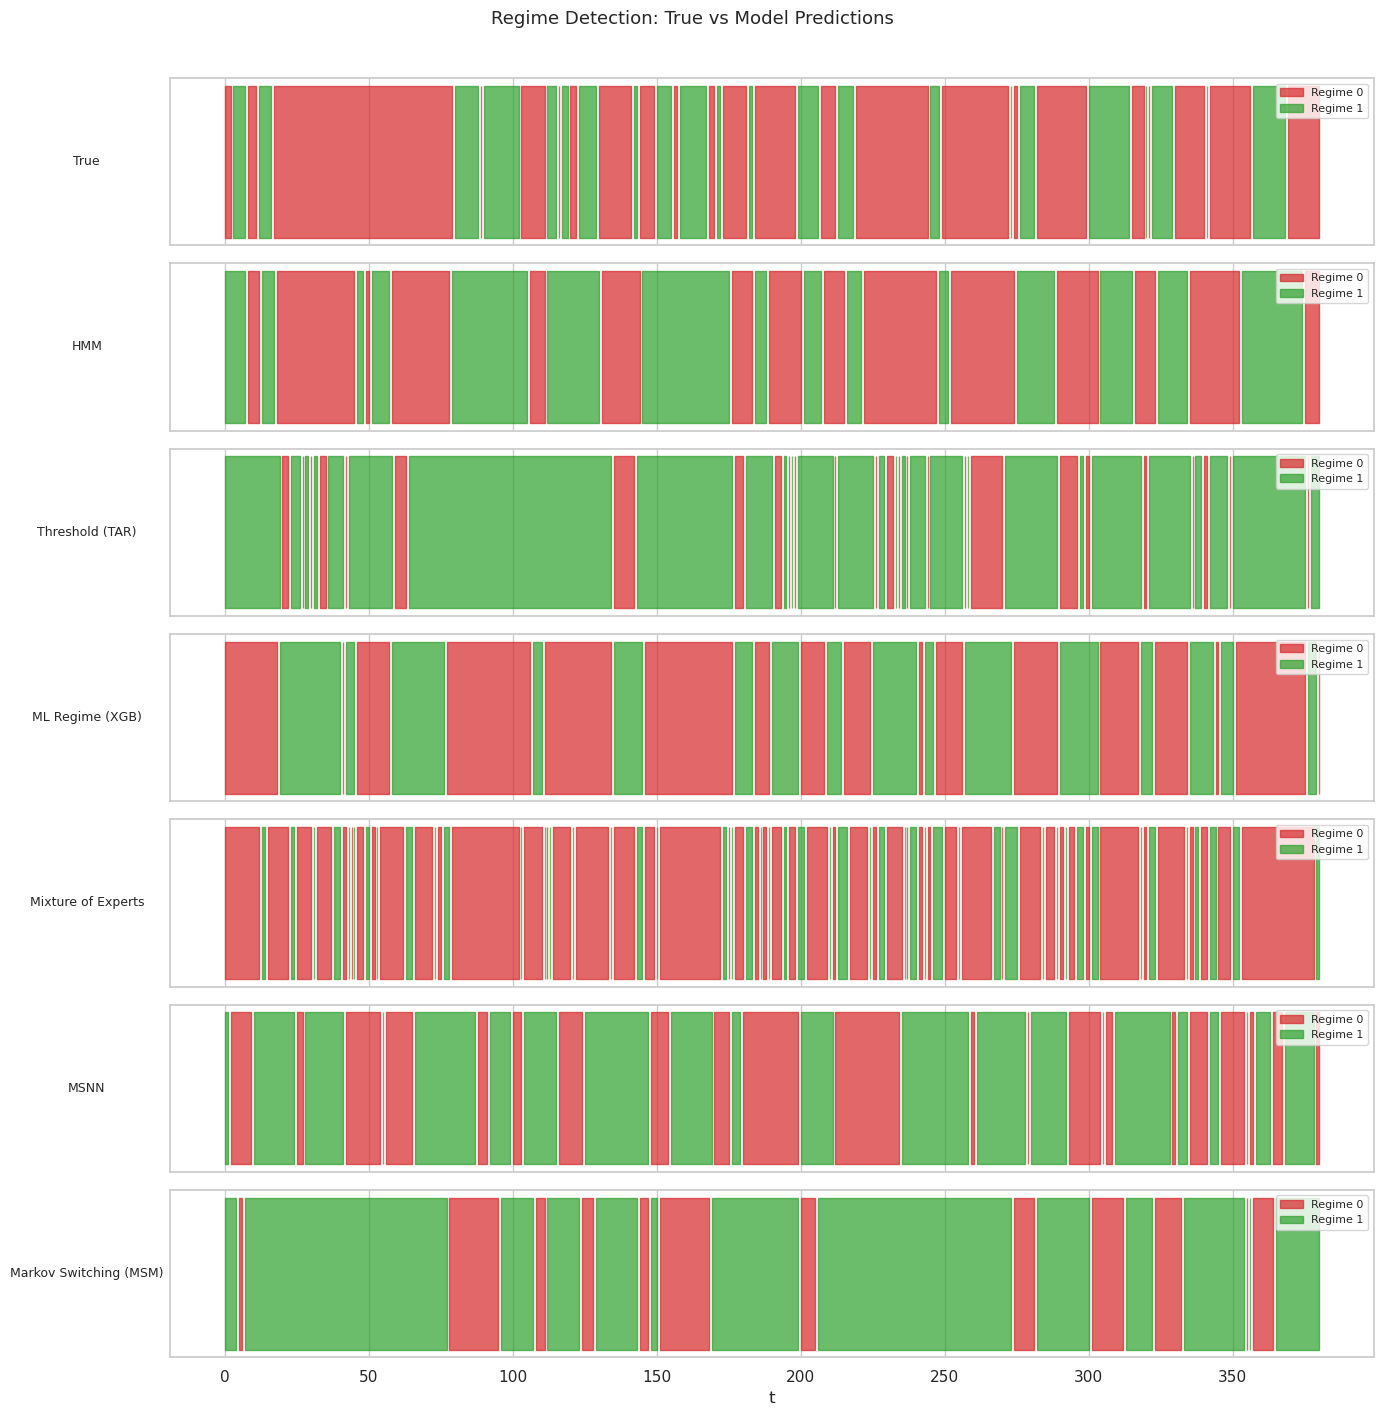

In [5]:
fig = plot_regime_comparison(true_regimes, pred_regimes)
save_figure(fig, '02_regime_comparison')
plt.show()

## 4. Forecast Accuracy

In [6]:
y_true = df_train['y'].to_numpy()
predictions = {}
results = []

for name, model in models.items():
    try:
        y_pred = model.predict(df_train)
        predictions[name] = y_pred
        results.append({
            'model': name,
            'rmse': forecast_rmse(y_true, y_pred),
            'mae': forecast_mae(y_true, y_pred),
            'dir_acc': directional_accuracy(y_true, y_pred),
            'regime_acc': regime_accuracy(true_regimes, pred_regimes.get(name, np.zeros_like(true_regimes))),
            'ari': adjusted_rand_regime(true_regimes, pred_regimes.get(name, np.zeros_like(true_regimes))),
        })
    except Exception as e:
        print(f'{name} predict failed: {e}')

results_df = pd.DataFrame(results)
print('In-sample forecast performance:')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

In-sample forecast performance:
                 model   rmse    mae  dir_acc  regime_acc     ari
                   HMM 1.5818 1.1914   0.5079      0.7507  0.2494
       Threshold (TAR) 1.5248 1.1420   0.5211      0.5013 -0.0450
       ML Regime (XGB) 0.3270 0.2499   0.9053      0.6640  0.1028
    Mixture of Experts 1.2932 0.9845   0.6368      0.5354 -0.0238
                  MSNN 0.5216 0.2833   0.8868      0.5144 -0.0058
Markov Switching (MSM) 1.6655 1.2433   0.4658      0.8058  0.3569


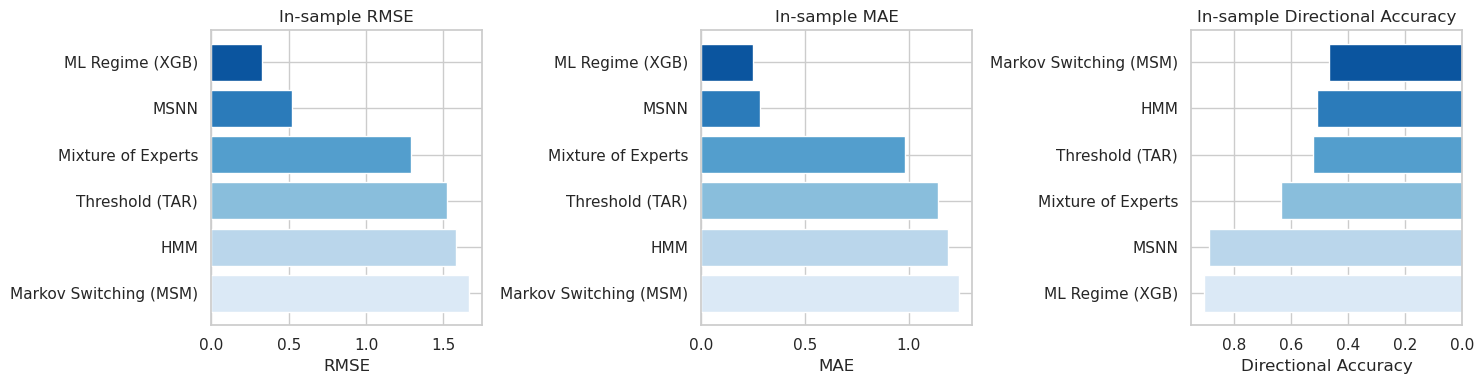

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, ylabel in zip(axes, ['rmse', 'mae', 'dir_acc'],
                               ['RMSE', 'MAE', 'Directional Accuracy']):
    df_sorted = results_df.sort_values(metric)
    colors = sns.color_palette('Blues_r', len(df_sorted))
    ax.barh(df_sorted['model'], df_sorted[metric], color=colors)
    ax.set_xlabel(ylabel)
    ax.set_title(f'In-sample {ylabel}')
    if metric == 'dir_acc':
        ax.invert_xaxis()
        ax.invert_yaxis()
    else:
        ax.invert_yaxis()

plt.tight_layout()
save_figure(fig, '02_insample_performance')
plt.show()

## 5. Per-Regime RMSE Breakdown

In [8]:
print('RMSE broken down by true regime:')
print(f'{"Model":<25} {"Recession RMSE":<18} {"Expansion RMSE":<18}')
print('-' * 61)

for name, y_pred in predictions.items():
    cond_rmse = regime_conditional_rmse(y_true, y_pred, true_regimes)
    rec = cond_rmse.get(0, float('nan'))
    exp = cond_rmse.get(1, float('nan'))
    print(f'{name:<25} {rec:<18.4f} {exp:<18.4f}')

RMSE broken down by true regime:
Model                     Recession RMSE     Expansion RMSE    
-------------------------------------------------------------
HMM                       1.8376             0.9019            
Threshold (TAR)           1.7567             0.9249            
ML Regime (XGB)           0.3419             0.2963            
Mixture of Experts        1.4330             0.9677            
MSNN                      0.6042             0.3041            
Markov Switching (MSM)    1.9341             0.9525            


## 6. Predicted vs True: Time Series

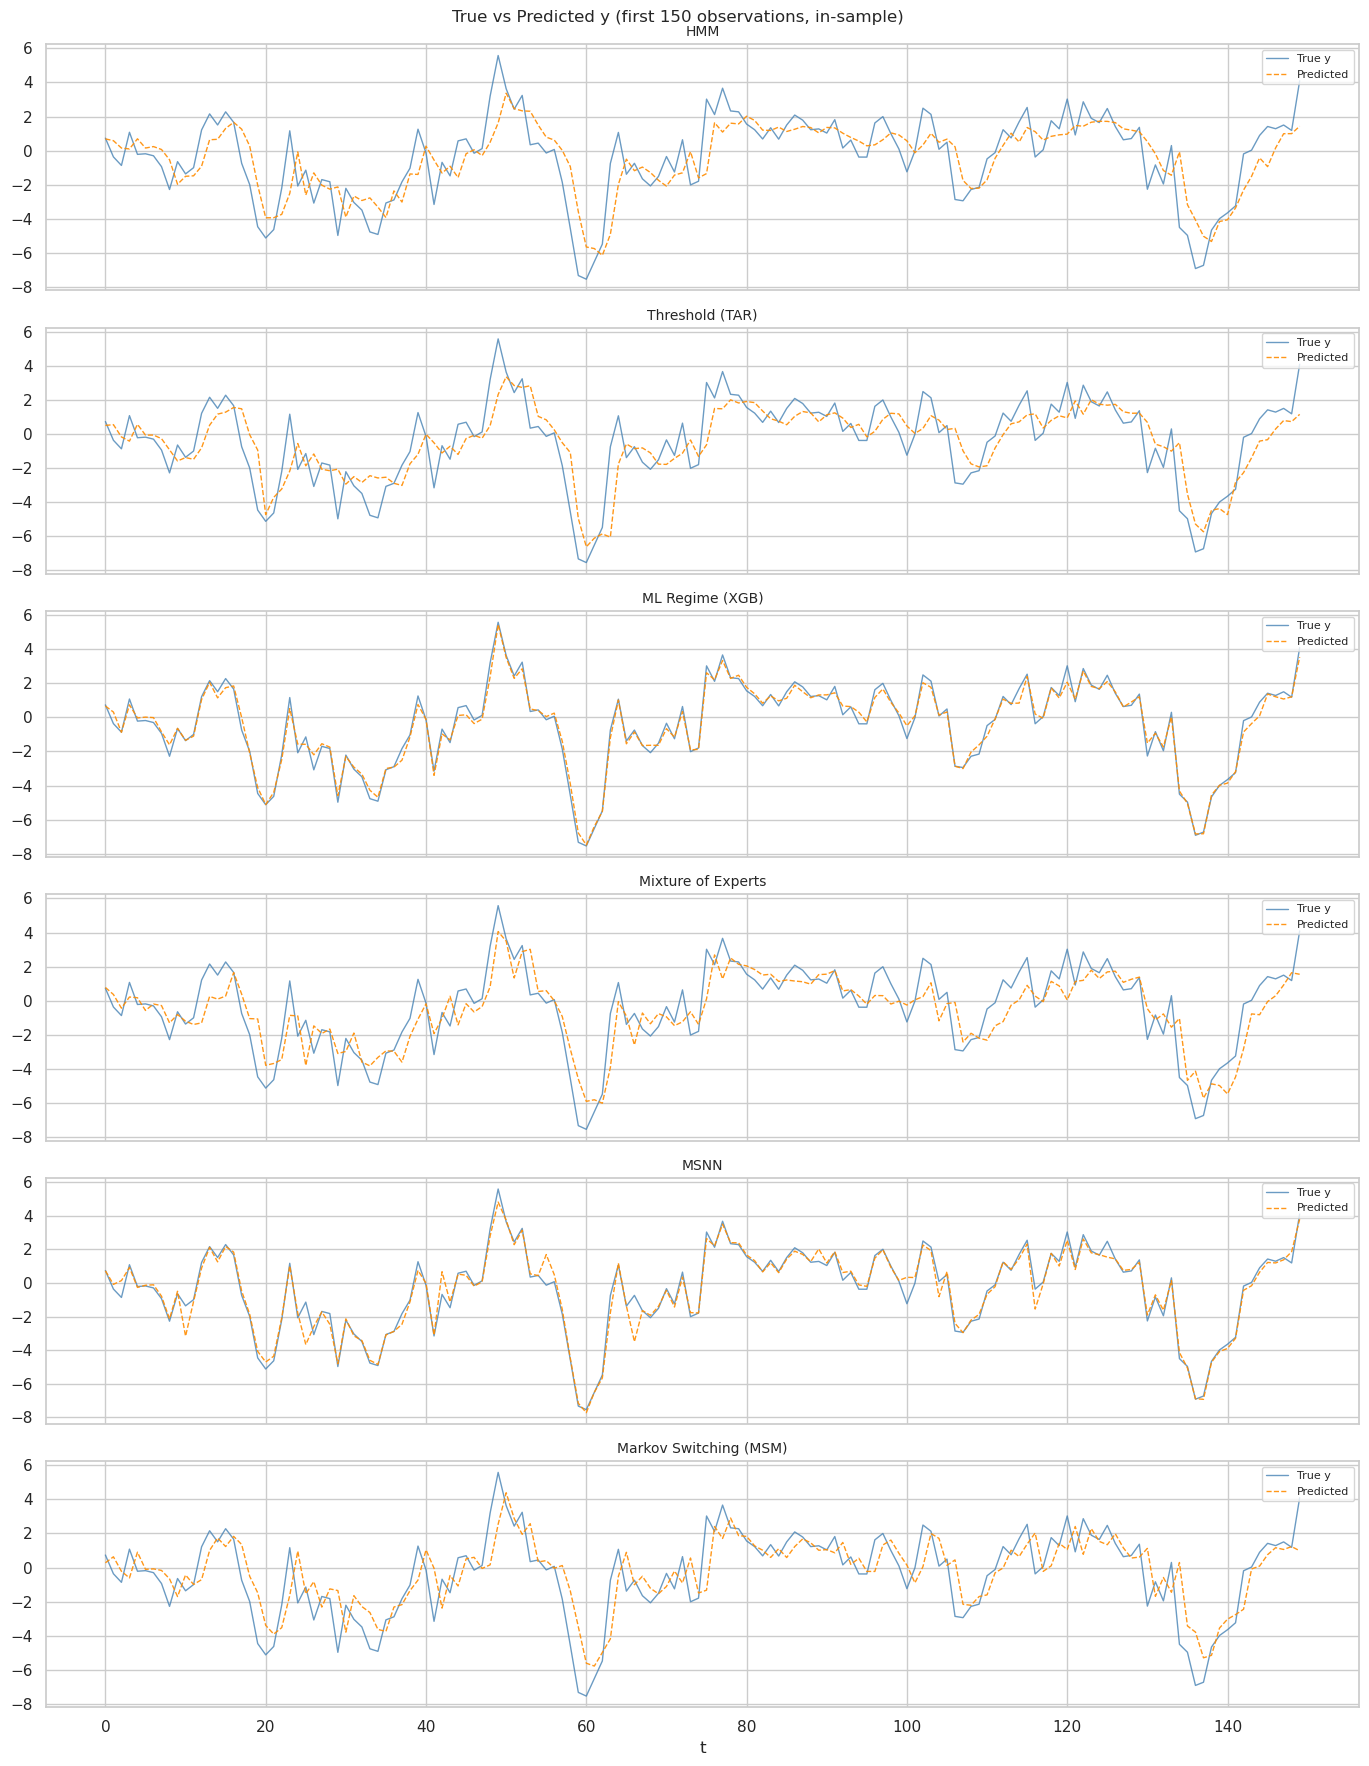

In [9]:
n_plot = min(150, len(df_train))
t = np.arange(n_plot)

fig, axes = plt.subplots(len(predictions), 1, figsize=(14, 3 * len(predictions)), sharex=True)
if len(predictions) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.plot(t, y_true[:n_plot], color='steelblue', lw=1, label='True y', alpha=0.8)
    ax.plot(t, y_pred[:n_plot], color='darkorange', lw=1, ls='--', label='Predicted', alpha=0.9)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('t')
fig.suptitle('True vs Predicted y (first 150 observations, in-sample)', fontsize=12)
plt.tight_layout()
save_figure(fig, '02_predictions_vs_true')
plt.show()

## 7. Save Results

In [10]:
results_df.to_csv(data_dir / 'insample_results.csv', index=False)
print('In-sample results saved.')

In-sample results saved.
